In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=1.1659124/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

# c1 - First look

In [14]:
logN_dict = {'HI': '14.8, -0.1, +0.1',
            'HeI': '<12.8',
            'CII': '<12.7',
            'CIII': '>12.1',
            'CIV': '13.64, -0.02, +0.02',
            'NIV': '13.1, -0.1, +0.1',
            'NV': '<12.9',
            'OIII': '14.35, -0.08, +0.08',
            'OIV': '14.50, -0.08, +0.08',
            'OV': '13.97, -0.02, +0.02',
            'OVI': '<13.4',
            'MgII': '<10.9',
            'MgX': '<13.2',
            'AlII': '<10.8',
            'AlIII': '<11.1',
            'SiII': '<11.8',
            'SIV': '<13.5',
            'SVI': '<13.1',
            'FeII': '<11.2',}

# c1 - Two-phase solution: low density phase

In [118]:
logN_dict = {#'HI': '14.8, -0.1, +0.1',
            #'HeI': '<12.8',
            #'CII': '<12.7',
            'CIII': '>12.1',
            'CIV': '13.64, -0.02, +0.02',
            'NIV': '13.1, -0.1, +0.1',
            'NV': '<12.9',
            'OIII': '<14.35',
            'OIV': '14.50, -0.08, +0.08',
            'OV': '<13.97',
            'OVI': '<13.4',
            #'MgII': '<10.9',
            'MgX': '<13.2',
            #'AlII': '<10.8',
            #'AlIII': '<11.1',
            #'SiII': '<11.8',
            'SIV': '<13.5',
            'SVI': '<13.1',}
            #'FeII': '<11.2',}

In [119]:
gen_logN_ratio_str(logN_dict['MgX'], logN_dict['OIV'])

'<-1.30, 0.16'

In [120]:
logN_ratio_dict = {'OIII/OIV': '<-0.2, 0.2',
                   'OV/OIV': '<-0.5, 0.2',
                   'OVI/OIV': '<-1.1, 0.2',
                   #'MgX/OIV': '<1.3, 0.2',
                   #'SIV/OIV': '<-1.0, 0.2',
                   #'SVI/OIV': '<-1.4, 0.2',
                   'NV/NIV': '<-0.2, 0.2',}
                   #'CIII/CIV': '>-1.5, 0.3'}

(-2.2, 2.5)

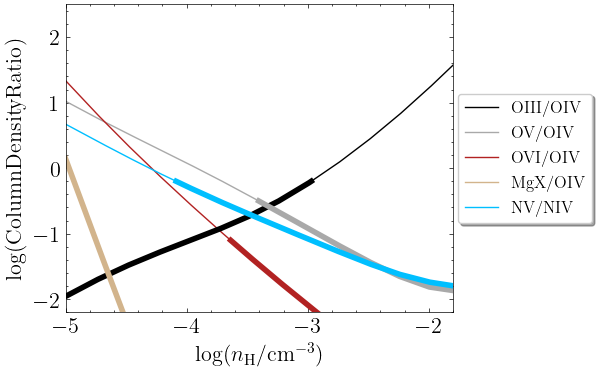

In [121]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.8)
ax.set_ylim(-2.2, 2.5)

In [56]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [57]:
pos = np.array(-3.2) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [58]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [59]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [06:28<00:00,  1.29it/s]


In [60]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_lo_c1.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_lo_c1.csv')

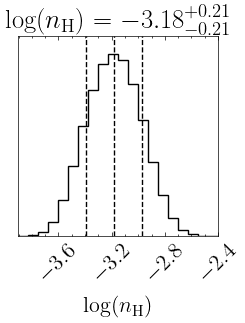

In [61]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [62]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [63]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

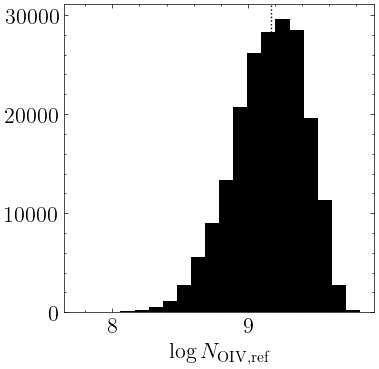

In [64]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{OIII, ref}}$')

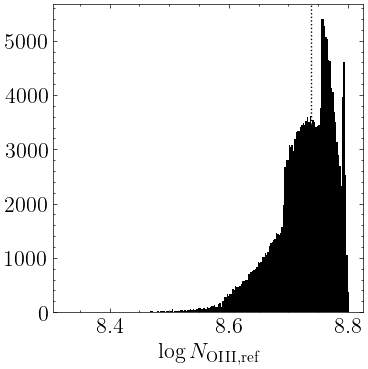

In [65]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['O+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIII, ref}}$')

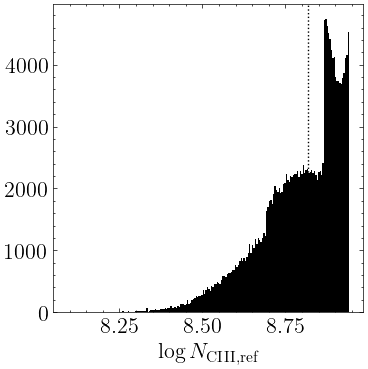

In [66]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['C+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [67]:
logN_offset = 14.50-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [68]:
logN_offset

5.326802460550521

Calculate the C/O ratio

In [69]:
logN_CIV_obs = np.random.normal(loc=13.64, scale=0.02, size=len(flat_samples_hdens))

In [70]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [71]:
get_quantiles(C_O_dist)

-0.07 -0.26 0.31


Calculate the N/O ratio

In [74]:
logN_NIV_obs = np.random.normal(loc=13.1, scale=0.1, size=len(flat_samples_hdens))

In [75]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [76]:
get_quantiles(N_O_dist)

-0.54 -0.31 0.35


Get yields

In [77]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

14.06 -0.06 0.04


Plot models

In [81]:
logN_dict = {#'HI': '14.8, -0.1, +0.1',
            #'HeI': '<12.8',
            #'CII': '<12.7',
            'CIII': '>12.1',
            'CIV': '13.64, -0.02, +0.02',
            'NIV': '13.1, -0.1, +0.1',
            'NV': '<12.9',
            'OIII': '14.35, -0.08, +0.08',
            'OIV': '14.50, -0.08, +0.08',
            'OV': '13.97, -0.02, +0.02',
            'OVI': '<13.4',
            #'MgII': '<10.9',
            'MgX': '<13.2',
            #'AlII': '<10.8',
            #'AlIII': '<11.1',
            #'SiII': '<11.8',
            'SIV': '<13.5',
            'SVI': '<13.1',}
            #'FeII': '<11.2',}

In [82]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

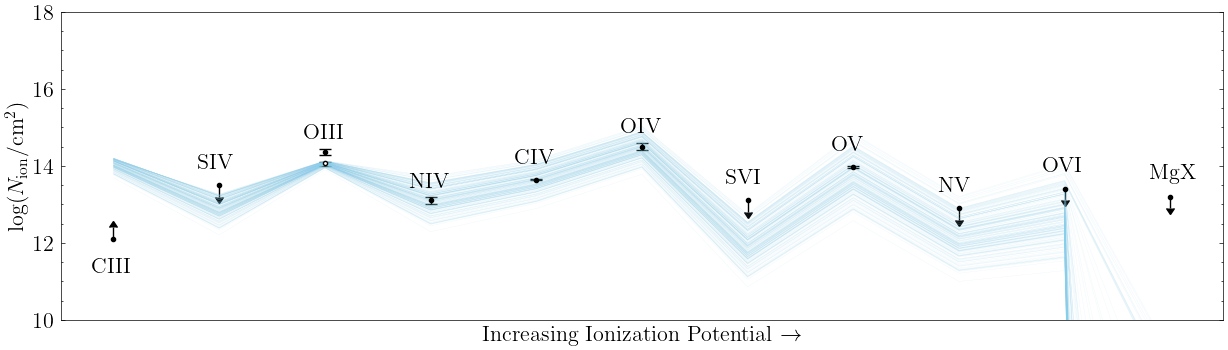

In [84]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.errorbar(x=2, y=14.06, yerr=[[0.06],[0.04]], color='black', linestyle='None', mfc='white',
        fmt='o', markersize=3, capsize=4)

#ax.errorbar(x=1, y=13.98, yerr=0.08, color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C':np.median(C_O_dist), 'N': np.median(N_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

Calculate residual for OIII

In [85]:
logN_OIII_tot = np.random.normal(loc=14.35, scale=0.08, size=1000)
logN_OIII_lo_dens = np.random.normal(loc=14.06, scale=0.06, size=1000)
logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_2683/398636094.py:3: RuntimeWarning: invalid value encountered in log10
  logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)


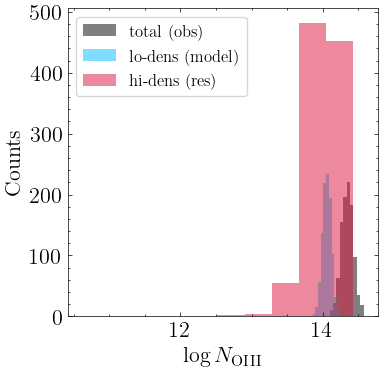

In [86]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_OIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_OIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_OIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [87]:
logN_OIII_hi_dens_clean = logN_OIII_hi_dens[~np.isnan(logN_OIII_hi_dens)]

In [88]:
get_quantiles(logN_OIII_hi_dens_clean)

14.03 -0.21 0.16


# c1 - Two-phase solution: high density phase

In [93]:
logN_dict = {#'HI': '14.8, -0.1, +0.1',
            #'HeI': '<12.8',
            #'CII': '<12.7',
            #'CIII': '>12.1',
            #'CIV': '13.64, -0.02, +0.02',
            #'NIV': '13.1, -0.1, +0.1',
            #'NV': '<12.9',
            'OIII': '14.0, -0.2, +0.2',
            'OIV': '<14.50',
            #'OV': '13.97, -0.02, +0.02',
            #'OVI': '<13.4',
            'MgII': '<10.9',
            #'MgX': '<13.2',
            #'AlII': '<10.8',
            #'AlIII': '<11.1',
            #'SiII': '<11.8',
            'SIV': '<13.5',
            #'SVI': '<13.1',}
            #'FeII': '<11.2',}

In [96]:
gen_logN_ratio_str(logN_dict['OIV'], logN_dict['OIII'])

'<0.50, 0.24'

In [97]:
logN_ratio_dict = {'MgII/OIII': '<-3.1, 0.2',
                   'SIV/OIII': '<-0.5, 0.2',
                   'OIV/OIII': '<0.5, 0.2'
                  }

(-5.0, 5.0)

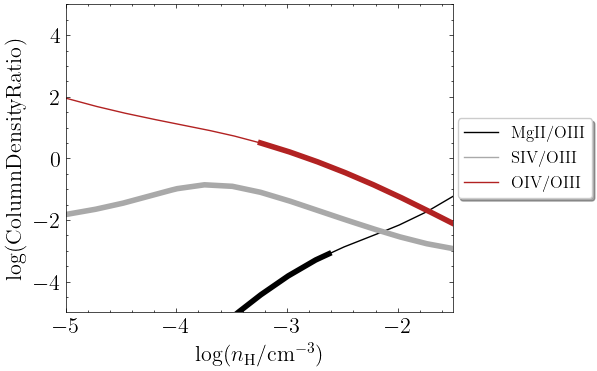

In [98]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [99]:
pos = np.array(-2.8) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [100]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [101]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [04:53<00:00,  1.70it/s]


In [102]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_hi_c1.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_hi_c1.csv')

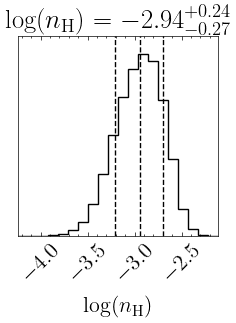

In [103]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [104]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [105]:
logN_offset = 14.0-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [106]:
logN_offset

5.333545288322959

Plot models

In [108]:
logN_dict = {#'HI': '14.8, -0.1, +0.1',
            #'HeI': '<12.8',
            #'CII': '<12.7',
            #'CIII': '>12.1',
            #'CIV': '13.64, -0.02, +0.02',
            #'NIV': '13.1, -0.1, +0.1',
            #'NV': '<12.9',
            'OIII': '14.0, -0.2, +0.2',
            'OIV': '<14.50',
            #'OV': '13.97, -0.02, +0.02',
            #'OVI': '<13.4',
            'MgII': '<10.9',
            #'MgX': '<13.2',
            #'AlII': '<10.8',
            #'AlIII': '<11.1',
            #'SiII': '<11.8',
            'SIV': '<13.5',}
            #'SVI': '<13.1',}
            #'FeII': '<11.2',}

In [109]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

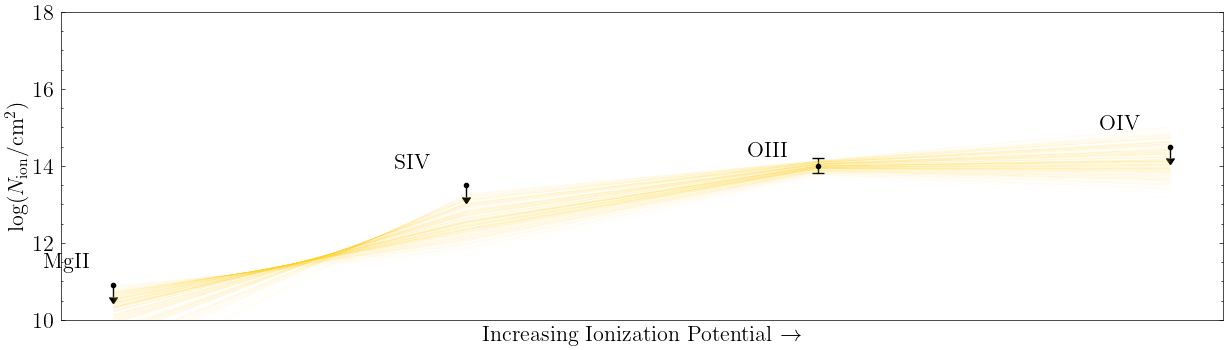

In [110]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='gold', lw=.2, alpha=.1)

In [111]:
get_cloud_size(14.8, -2.9, species_logN_interp)

0.37113388083961985

# c2 - First look

In [112]:
logN_dict = {'HI' : '14.1, -0.2, +0.2',
            'HeI' : '<12.8',
            'CII' : '<12.7',
            'CIII' : '>12.1',
            'CIV' : '13.38, -0.02, +0.02',
            'NIV' : '12.9, -0.1, +0.1',
            'NV' : '<12.8',
            'OIII' : '13.9, -0.1, +0.1',
            'OIV' : '14.21, -0.07, +0.07',
            'OV' : '	13.5, -0.2, +0.2',
            'OVI' : '<13.4',
            'MgII' : '<10.9',
            'MgX' : '<13.2',
            'AlII' : '<10.8',
            'AlIII' : '<11.1',
            'SiII' : '<11.8',
            'SIV' : '<13.6',
            'SVI' : '<13.1',
            'FeII' : '<11.2',}

# c2 - Two-phase solution: low density phase

In [122]:
logN_dict = {#'HI' : '14.1, -0.2, +0.2',
            #'HeI' : '<12.8',
            #'CII' : '<12.7',
            'CIII' : '>12.1',
            'CIV' : '13.38, -0.02, +0.02',
            'NIV' : '12.9, -0.1, +0.1',
            'NV' : '<12.8',
            'OIII' : '<13.9',
            'OIV' : '14.21, -0.07, +0.07',
            'OV' : '<13.5',
            'OVI' : '<13.4',
            #'MgII' : '<10.9',
            'MgX' : '<13.2',
            #'AlII' : '<10.8',
            #'AlIII' : '<11.1',
            #'SiII' : '<11.8',
            'SIV' : '<13.6',
            'SVI' : '<13.1',}
            #'FeII' : '<11.2',}

In [128]:
gen_logN_ratio_str(logN_dict['CIII'], logN_dict['CIV'])

'>-1.28, 0.33'

In [133]:
logN_ratio_dict = {'OIII/OIV': '<-0.3, 0.2',
                   'OV/OIV': '<-0.7, 0.2',
                   'OVI/OIV': '<-0.8, 0.2',
                   #'MgX/OIV': '<1.0, 0.2',
                   #'SIV/OIV': '<-0.6, 0.2',
                   'SVI/OIV': '<-1.1, 0.2',
                   'NV/NIV': '<-0.1, 0.2',}
                   #'CIII/CIV': '>-1.3, 0.3'}

(-2.2, 2.5)

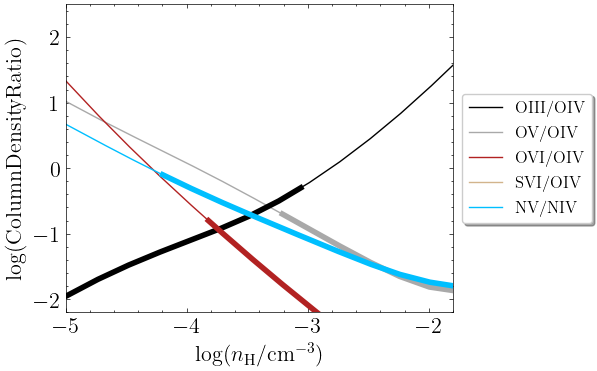

In [134]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.8)
ax.set_ylim(-2.2, 2.5)

In [135]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [136]:
pos = np.array(-3.1) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [137]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [138]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [08:10<00:00,  1.02it/s]


In [139]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_lo_c2.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_lo_c2.csv')

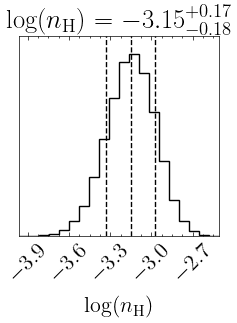

In [140]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [141]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [142]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

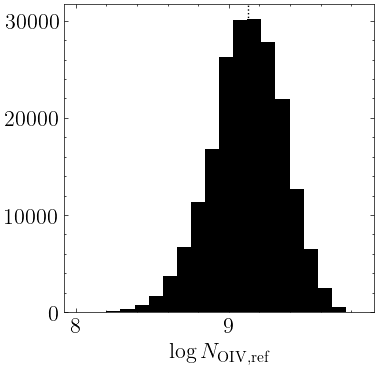

In [143]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{OIII, ref}}$')

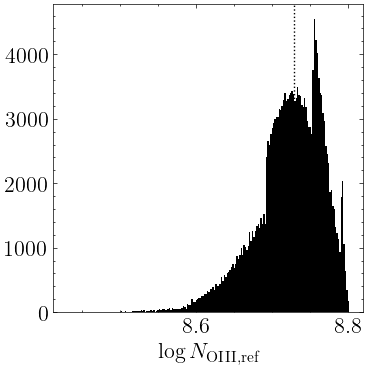

In [144]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['O+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIII, ref}}$')

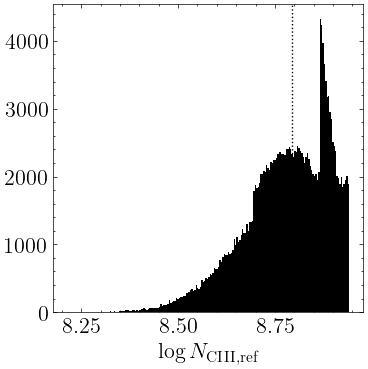

In [145]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['C+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [146]:
logN_offset = 14.21-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [147]:
logN_offset

5.082346110087615

Calculate the C/O ratio

In [148]:
logN_CIV_obs = np.random.normal(loc=13.38, scale=0.02, size=len(flat_samples_hdens))

In [149]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [150]:
get_quantiles(C_O_dist)

-0.04 -0.24 0.26


Calculate the N/O ratio

In [151]:
logN_NIV_obs = np.random.normal(loc=12.9, scale=0.1, size=len(flat_samples_hdens))

In [152]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [153]:
get_quantiles(N_O_dist)

-0.44 -0.28 0.3


Get yields

In [154]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

13.81 -0.05 0.04


Plot models

In [155]:
logN_dict = {#'HI' : '14.1, -0.2, +0.2',
            #'HeI' : '<12.8',
            #'CII' : '<12.7',
            'CIII' : '>12.1',
            'CIV' : '13.38, -0.02, +0.02',
            'NIV' : '12.9, -0.1, +0.1',
            'NV' : '<12.8',
            'OIII' : '13.9, -0.1, +0.1',
            'OIV' : '14.21, -0.07, +0.07',
            'OV' : '13.5, -0.2, +0.2',
            'OVI' : '<13.4',
            #'MgII' : '<10.9',
            'MgX' : '<13.2',
            #'AlII' : '<10.8',
            #'AlIII' : '<11.1',
            #'SiII' : '<11.8',
            'SIV' : '<13.6',
            'SVI' : '<13.1',}
            #'FeII' : '<11.2',}

In [156]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

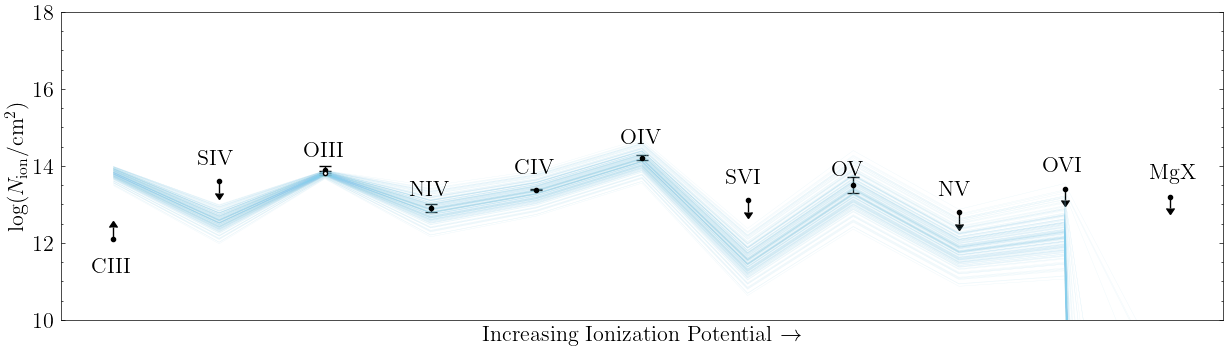

In [158]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.errorbar(x=2, y=13.81, yerr=0.05, color='black', linestyle='None', mfc='white',
        fmt='o', markersize=3, capsize=4)

#ax.errorbar(x=1, y=13.98, yerr=0.08, color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C':np.median(C_O_dist), 'N': np.median(N_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

Calculate residual for OIII

In [159]:
logN_OIII_tot = np.random.normal(loc=13.9, scale=0.1, size=1000)
logN_OIII_lo_dens = np.random.normal(loc=13.81, scale=0.05, size=1000)
logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_2683/688810399.py:3: RuntimeWarning: invalid value encountered in log10
  logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)


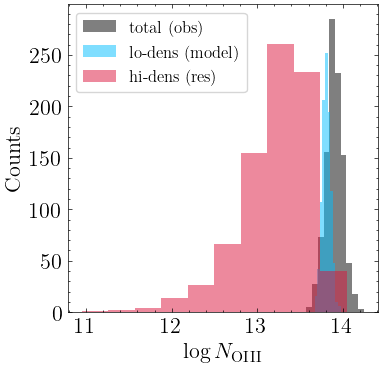

In [160]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_OIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_OIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_OIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [161]:
logN_OIII_hi_dens_clean = logN_OIII_hi_dens[~np.isnan(logN_OIII_hi_dens)]

In [162]:
get_quantiles(logN_OIII_hi_dens_clean)

13.29 -0.44 0.32


# c2 - Two-phase solution: high density phase

In [163]:
logN_dict = {#'HI' : '14.1, -0.2, +0.2',
            #'HeI' : '<12.8',
            #'CII' : '<12.7',
            #'CIII' : '>12.1',
            #'CIV' : '13.38, -0.02, +0.02',
            #'NIV' : '12.9, -0.1, +0.1',
            #'NV' : '<12.8',
            'OIII' : '13.3, -0.4, +0.3',
            'OIV' : '<14.21',
            #'OV' : '13.5, -0.2, +0.2',
            #'OVI' : '<13.4',
            'MgII' : '<10.9',
            #'MgX' : '<13.2',
            #'AlII' : '<10.8',
            #'AlIII' : '<11.1',
            #'SiII' : '<11.8',
            'SIV' : '<13.6',}
            #'SVI' : '<13.1',
            #'FeII' : '<11.2',}

In [166]:
gen_logN_ratio_str(logN_dict['MgII'], logN_dict['OIII'])

'<-2.40, 0.33'

In [167]:
logN_ratio_dict = {'MgII/OIII': '<-2.4, 0.3',
                   'SIV/OIII': '<0.3, 0.3',
                   'OIV/OIII': '<0.9, 0.3'
                  }

(-5.0, 5.0)

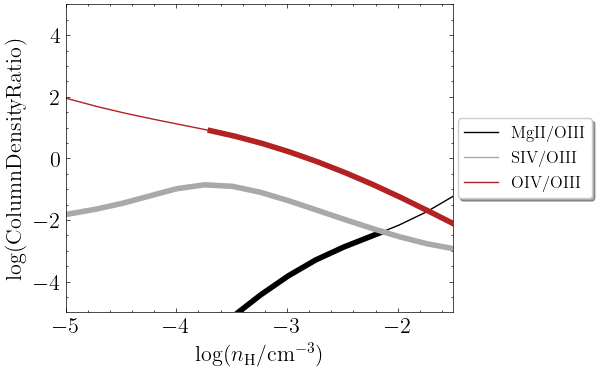

In [168]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [169]:
pos = np.array(-2.6) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [170]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [171]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [04:52<00:00,  1.71it/s]


In [172]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_hi_c2.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_hi_c2.csv')

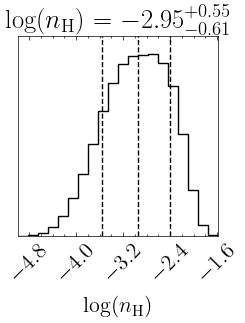

In [173]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [174]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [175]:
logN_offset = 13.3-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [176]:
logN_offset

4.64107343221127

Plot models

In [177]:
logN_dict = {#'HI' : '14.1, -0.2, +0.2',
            #'HeI' : '<12.8',
            #'CII' : '<12.7',
            #'CIII' : '>12.1',
            #'CIV' : '13.38, -0.02, +0.02',
            #'NIV' : '12.9, -0.1, +0.1',
            #'NV' : '<12.8',
            'OIII' : '13.3, -0.4, +0.3',
            'OIV' : '<14.21',
            #'OV' : '13.5, -0.2, +0.2',
            #'OVI' : '<13.4',
            'MgII' : '<10.9',
            #'MgX' : '<13.2',
            #'AlII' : '<10.8',
            #'AlIII' : '<11.1',
            #'SiII' : '<11.8',
            'SIV' : '<13.6',}
            #'SVI' : '<13.1',
            #'FeII' : '<11.2',}

In [178]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

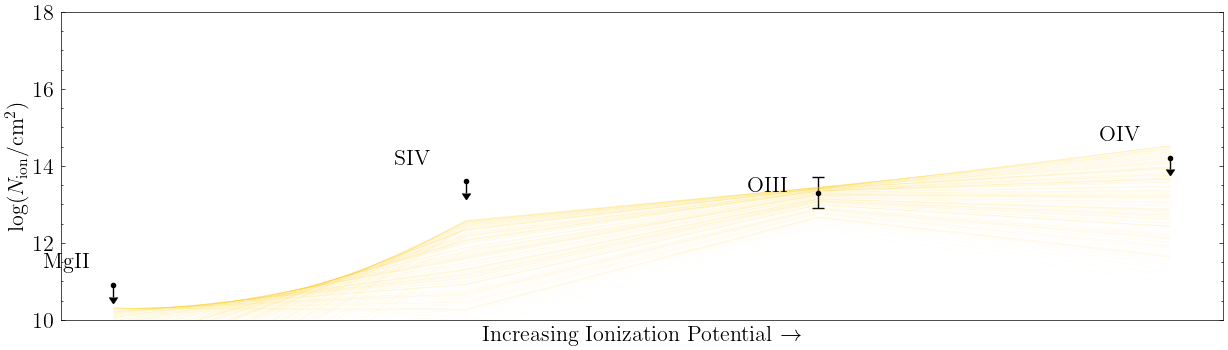

In [179]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='gold', lw=.2, alpha=.1)

In [180]:
get_cloud_size(14.1, -2.9, species_logN_interp)

0.0738439862038874

# c3 - First look

In [182]:
logN_dict = {'HI' : '14.3, -0.2, +0.1',
            'HeI' : '<12.8',
            'CII' : '<12.8',
            'CIII' : '>12.9',
            'CIV' : '13.45, -0.03, +0.03',
            'NIV' : '13.0, -0.1, +0.1',
            'NV' : '<12.9',
            'OIII' : '13.63, -0.07, +0.07',
            'OIV' : '14.32, -0.06, +0.06',
            'OV' : '14.46, -0.04, +0.06',
            'OVI' : '<13.4',
            'MgII' : '<11.0',
            'MgX' : '<13.2',
            'AlII' : '<10.9',
            'AlIII' : '<11.2',
            'SiII' : '<11.9',
            'SIV' : '<13.6',
            'SVI' : '<13.0',
            'FeII' : '<11.3',}

# c3 - Two-phase solution: low density phase

In [183]:
logN_dict = {#'HI' : '14.3, -0.2, +0.1',
            #'HeI' : '<12.8',
            #'CII' : '<12.8',
            'CIII' : '>12.9',
            'CIV' : '13.45, -0.03, +0.03',
            'NIV' : '13.0, -0.1, +0.1',
            'NV' : '<12.9',
            'OIII' : '<13.63',
            'OIV' : '14.32, -0.06, +0.06',
            'OV' : '<14.46',
            'OVI' : '<13.4',
            #'MgII' : '<11.0',
            'MgX' : '<13.2',
            #'AlII' : '<10.9',
            #'AlIII' : '<11.2',
            #'SiII' : '<11.9',
            'SIV' : '<13.6',
            'SVI' : '<13.0',}
            #'FeII' : '<11.3',}

In [192]:
gen_logN_ratio_str(logN_dict['CIII'], logN_dict['CIV'])

'>-0.55, 0.33'

In [199]:
logN_ratio_dict = {'OIII/OIV': '<-0.7, 0.2',
                   'OV/OIV': '<0.2, 0.2',
                   'OVI/OIV': '<-0.9, 0.2',
                   #'MgX/OIV': '<-1.1, 0.2',
                   #'SIV/OIV': '<-0.7, 0.2',
                   #'SVI/OIV': '<-1.3, 0.2',
                   'NV/NIV': '<-0.1, 0.2',}
                   #'CIII/CIV': '>-1.3, 0.3'}

(-2.2, 2.5)

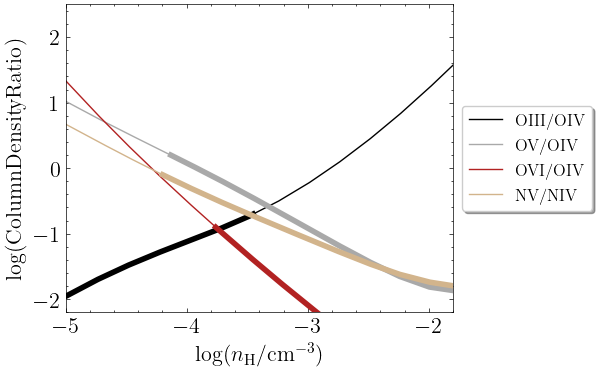

In [200]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.8)
ax.set_ylim(-2.2, 2.5)

In [201]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [202]:
pos = np.array(-3.6) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [203]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [204]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [06:34<00:00,  1.27it/s]


In [205]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_lo_c3.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_lo_c3.csv')

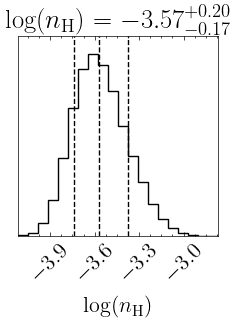

In [206]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [207]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [208]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

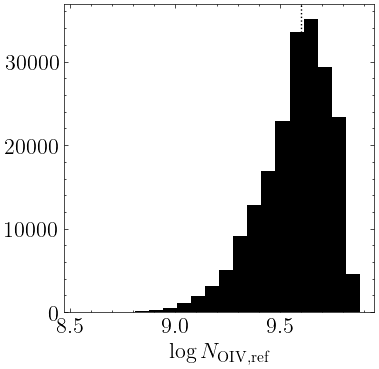

In [209]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{OIII, ref}}$')

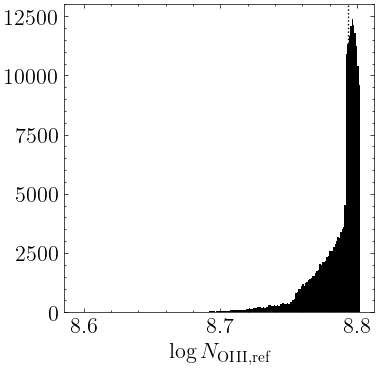

In [210]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['O+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIII, ref}}$')

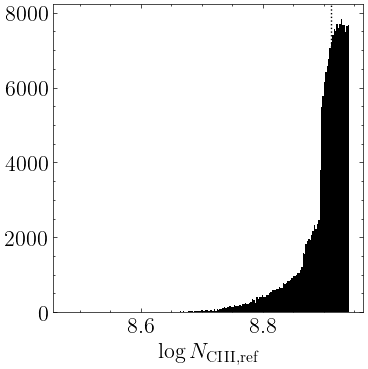

In [211]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['C+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [212]:
logN_offset = 14.32-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [213]:
logN_offset

4.720463842138063

Calculate the C/O ratio

In [214]:
logN_CIV_obs = np.random.normal(loc=13.45, scale=0.03, size=len(flat_samples_hdens))

In [215]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [216]:
get_quantiles(C_O_dist)

-0.08 -0.11 0.19


Calculate the N/O ratio

In [217]:
logN_NIV_obs = np.random.normal(loc=13.0, scale=0.1, size=len(flat_samples_hdens))

In [218]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [219]:
get_quantiles(N_O_dist)

-0.53 -0.18 0.25


Get yields

In [220]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

13.51 -0.02 0.01


Plot models

In [222]:
logN_dict = {#'HI' : '14.3, -0.2, +0.1',
            #'HeI' : '<12.8',
            #'CII' : '<12.8',
            'CIII' : '>12.9',
            'CIV' : '13.45, -0.03, +0.03',
            'NIV' : '13.0, -0.1, +0.1',
            'NV' : '<12.9',
            'OIII' : '13.63, -0.07, +0.07',
            'OIV' : '14.32, -0.06, +0.06',
            'OV' : '14.46, -0.04, +0.06',
            'OVI' : '<13.4',
            #'MgII' : '<11.0',
            'MgX' : '<13.2',
            #'AlII' : '<10.9',
            #'AlIII' : '<11.2',
            #'SiII' : '<11.9',
            'SIV' : '<13.6',
            'SVI' : '<13.0',}
            #'FeII' : '<11.3',}

In [223]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

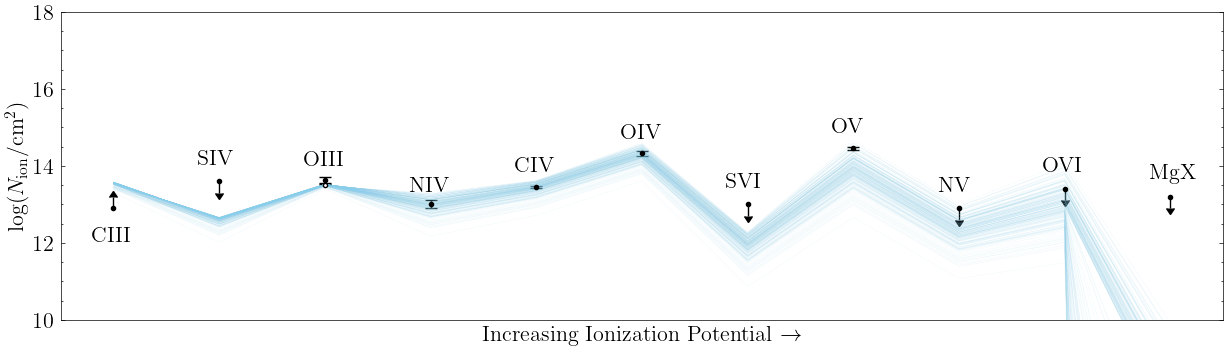

In [225]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.errorbar(x=2, y=13.51, yerr=0.02, color='black', linestyle='None', mfc='white',
        fmt='o', markersize=3, capsize=4)

#ax.errorbar(x=1, y=13.98, yerr=0.08, color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C':np.median(C_O_dist), 'N': np.median(N_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

Calculate residual for OIII

In [238]:
logN_OIII_tot = np.random.normal(loc=13.63, scale=0.07, size=1000)
logN_OIII_lo_dens = np.random.normal(loc=13.51, scale=0.02, size=1000)
logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_2683/3558195957.py:3: RuntimeWarning: invalid value encountered in log10
  logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)


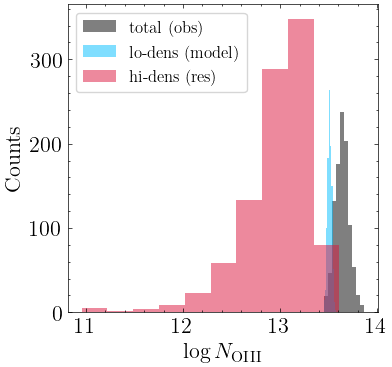

In [239]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_OIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_OIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_OIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [240]:
logN_OIII_hi_dens_clean = logN_OIII_hi_dens[~np.isnan(logN_OIII_hi_dens)]

In [241]:
get_quantiles(logN_OIII_hi_dens_clean)

13.04 -0.34 0.22


# c3 - Two-phase solution: high density phase

In [251]:
logN_dict = {#'HI' : '14.3, -0.2, +0.1',
            #'HeI' : '<12.8',
            #'CII' : '<12.8',
            #'CIII' : '>12.9',
            #'CIV' : '13.45, -0.03, +0.03',
            #'NIV' : '13.0, -0.1, +0.1',
            #'NV' : '<12.9',
            'OIII' : '13.0, -0.3, +0.2',
            'OIV' : '<14.32',
            'OV' : '<14.46',
            'OVI' : '<13.4',
            'MgII' : '<11.0',
            #'MgX' : '<13.2',
            #'AlII' : '<10.9',
            #'AlIII' : '<11.2',
            'SiII' : '<11.9',
            'SIV' : '<13.6',}
            #'SVI' : '<13.0',
            #'FeII' : '<11.3',}

In [253]:
gen_logN_ratio_str(logN_dict['OVI'], logN_dict['OIII'])

'<0.40, 0.24'

In [256]:
logN_ratio_dict = {'MgII/OIII': '<-2.0, 0.2',
                   #'SiII/OIII': '<-1.1, 0.2',
                   #'SIV/OIII': '<0.3, 0.2',
                   'OIV/OIII': '<1.3, 0.2',
                   'OV/OIII': '<1.5, 0.2',
                   'OVI/OIII': '<0.4, 0.2'
                  }

(-5.0, 5.0)

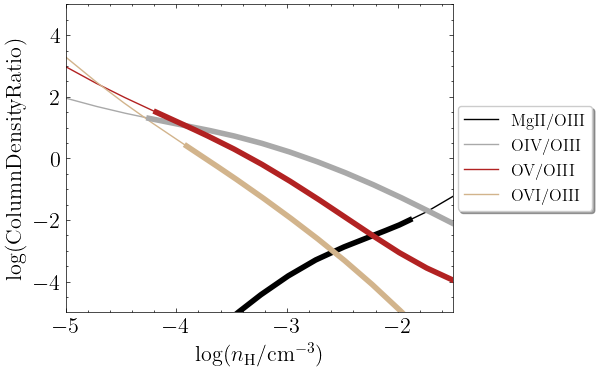

In [257]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [258]:
pos = np.array(-3) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [259]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [260]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [06:29<00:00,  1.28it/s]


In [261]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_hi_c3.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_hi_c3.csv')

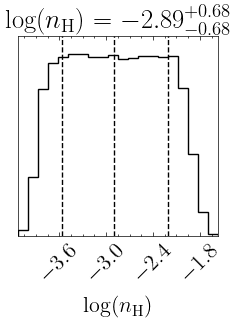

In [262]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [263]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [269]:
logN_offset = 13.0-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [270]:
logN_offset

4.351142133065258

Plot models

In [271]:
logN_dict = {#'HI' : '14.3, -0.2, +0.1',
            #'HeI' : '<12.8',
            #'CII' : '<12.8',
            #'CIII' : '>12.9',
            #'CIV' : '13.45, -0.03, +0.03',
            #'NIV' : '13.0, -0.1, +0.1',
            #'NV' : '<12.9',
            'OIII' : '13.0, -0.3, +0.2',
            'OIV' : '<14.32',
            'OV' : '<14.46',
            'OVI' : '<13.4',
            'MgII' : '<11.0',
            #'MgX' : '<13.2',
            #'AlII' : '<10.9',
            #'AlIII' : '<11.2',
            'SiII' : '<11.9',
            'SIV' : '<13.6',}
            #'SVI' : '<13.0',
            #'FeII' : '<11.3',}

In [272]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

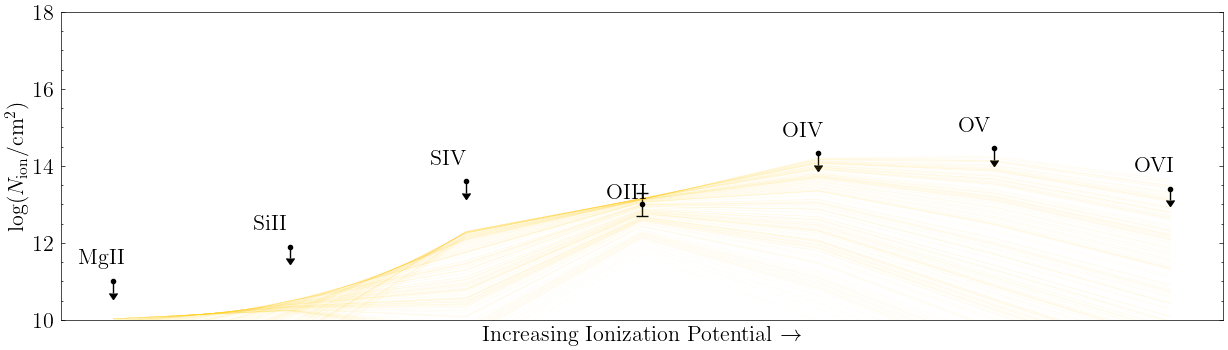

In [273]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='gold', lw=.2, alpha=.1)

In [274]:
get_cloud_size(14.3, -2.9, species_logN_interp)

0.11708342841165569

# c4 - First look

In [275]:
logN_dict = {'HI' : '14.5, -0.1, +0.1',
            'HeI' : '<12.8',
            'CII' : '<12.7',
            'CIII' : '<12.8',
            'CIV' : '13.52, -0.03, +0.03',
            'NIV' : '13.0, -0.1, +0.1',
            'NV' : '<12.9',
            'OIII' : '13.6, -0.1, +0.1',
            'OIV' : '13.9, -0.2, +0.1',
            'OV' : '<12.2',
            'OVI' : '14.1, -0.1, +0.1',
            'MgII' : '<11.0',
            'MgX' : '<13.2',
            'AlII' : '<10.8',
            'AlIII' : '<11.2',
            'SiII' : '<11.8',
            'SIV' : '<13.6',
            'SVI' : '<13.1',
            'FeII' : '<11.2',}

# c4 - Two-phase solution: low density phase

In [280]:
logN_dict = {#'HI' : '14.5, -0.1, +0.1',
            #'HeI' : '<12.8',
            #'CII' : '<12.7',
            'CIII' : '<12.8',
            'CIV' : '13.52, -0.03, +0.03',
            'NIV' : '13.0, -0.1, +0.1',
            'NV' : '<12.9',
            'OIII' : '<13.6',
            'OIV' : '13.9, -0.2, +0.1',
            'OV' : '<12.2',
            'OVI' : '<14.1',
            #'MgII' : '<11.0',
            'MgX' : '<13.2',
            #'AlII' : '<10.8',
            #'AlIII' : '<11.2',
            #'SiII' : '<11.8',
            'SIV' : '<13.6',
            'SVI' : '<13.1',}
            #'FeII' : '<11.2',}

In [288]:
gen_logN_ratio_str(logN_dict['CIII'], logN_dict['CIV'])

'<-0.72, 0.14'

In [295]:
logN_ratio_dict = {'OIII/OIV': '<-0.3, 0.2',
                   #'OV/OIV': '<-1.7, 0.2',
                   'OVI/OIV': '<0.2, 0.2',
                   #'MgX/OIV': '<-0.7, 0.2',
                   #'SIV/OIV': '<-0.3, 0.2',
                   'SVI/OIV': '<-0.8, 0.2',
                   'NV/NIV': '<-0.1, 0.2',}
                   #'CIII/CIV': '<-0.7, 0.1'}

(-2.2, 2.5)

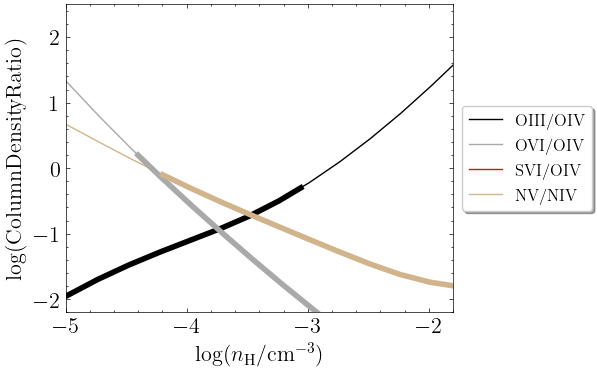

In [296]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.8)
ax.set_ylim(-2.2, 2.5)

In [297]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [298]:
pos = np.array(-3.6) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [299]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [300]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [06:29<00:00,  1.28it/s]


In [301]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_lo_c4.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_lo_c4.csv')

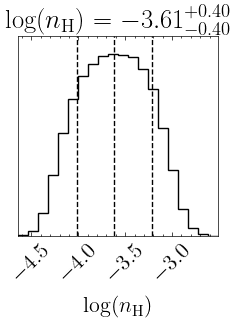

In [302]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [303]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [304]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

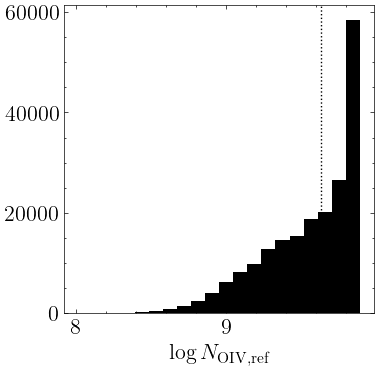

In [305]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{OIII, ref}}$')

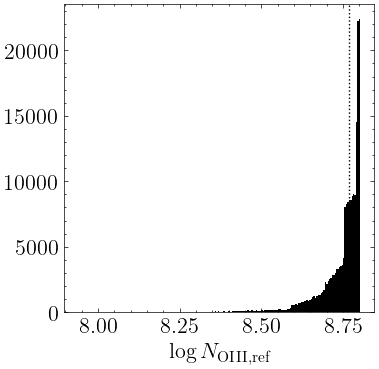

In [306]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['O+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIII, ref}}$')

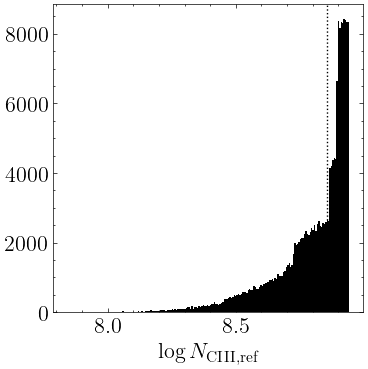

In [307]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['C+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [308]:
logN_offset = 13.9-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [309]:
logN_offset

4.266258608047954

Calculate the C/O ratio

In [310]:
logN_CIV_obs = np.random.normal(loc=13.52, scale=0.03, size=len(flat_samples_hdens))

In [311]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [312]:
get_quantiles(C_O_dist)

0.41 -0.13 0.4


Calculate the N/O ratio

In [313]:
logN_NIV_obs = np.random.normal(loc=13.0, scale=0.1, size=len(flat_samples_hdens))

In [314]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [315]:
get_quantiles(N_O_dist)

-0.11 -0.24 0.49


Get yields

In [316]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

13.04 -0.07 0.03


Plot models

In [317]:
logN_dict = {#'HI' : '14.5, -0.1, +0.1',
            #'HeI' : '<12.8',
            #'CII' : '<12.7',
            'CIII' : '<12.8',
            'CIV' : '13.52, -0.03, +0.03',
            'NIV' : '13.0, -0.1, +0.1',
            'NV' : '<12.9',
            'OIII' : '13.6, -0.1, +0.1',
            'OIV' : '13.9, -0.2, +0.1',
            'OV' : '<12.2',
            'OVI' : '14.1, -0.1, +0.1',
            #'MgII' : '<11.0',
            'MgX' : '<13.2',
            #'AlII' : '<10.8',
            #'AlIII' : '<11.2',
            #'SiII' : '<11.8',
            'SIV' : '<13.6',
            'SVI' : '<13.1',}
            #'FeII' : '<11.2',}

In [318]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

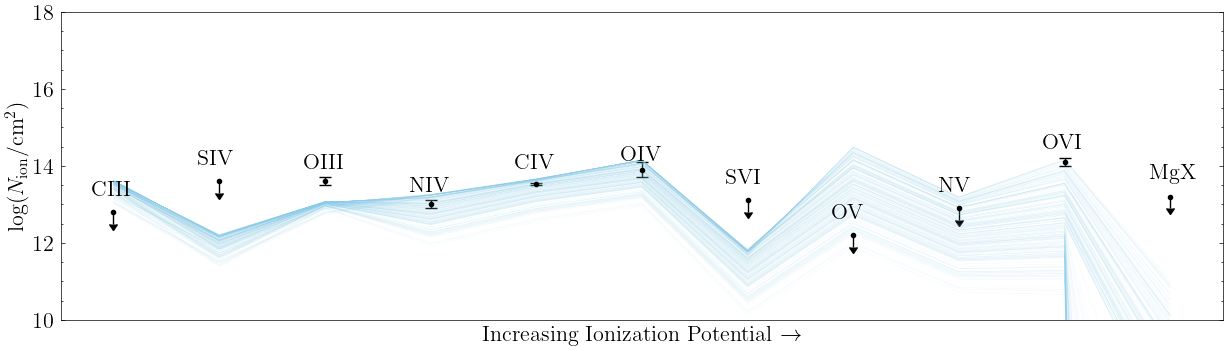

In [319]:
fig, ax = plot_column_densities_obs(logN_dict)

#ax.errorbar(x=2, y=13.51, yerr=0.02, color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

#ax.errorbar(x=1, y=13.98, yerr=0.08, color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C':np.median(C_O_dist), 'N': np.median(N_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

Calculate residual for OIII

In [325]:
logN_OIII_tot = np.random.normal(loc=13.6, scale=0.1, size=1000)
logN_OIII_lo_dens = np.random.normal(loc=13.04, scale=0.07, size=1000)
logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)

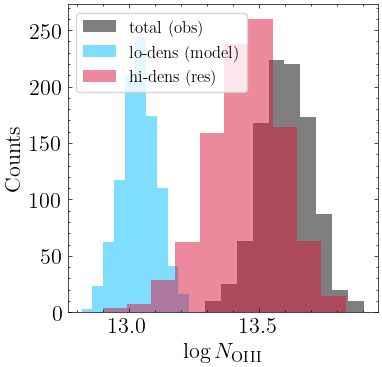

In [326]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_OIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_OIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_OIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [327]:
logN_OIII_hi_dens_clean = logN_OIII_hi_dens[~np.isnan(logN_OIII_hi_dens)]

In [328]:
get_quantiles(logN_OIII_hi_dens_clean)

13.46 -0.14 0.13


# c4 - Two-phase solution: high density phase

In [329]:
logN_dict = {#'HI' : '14.5, -0.1, +0.1',
            #'HeI' : '<12.8',
            #'CII' : '<12.7',
            #'CIII' : '<12.8',
            #'CIV' : '13.52, -0.03, +0.03',
            #'NIV' : '13.0, -0.1, +0.1',
            #'NV' : '<12.9',
            'OIII' : '13.5, -0.1, +0.1',
            'OIV' : '<13.9',
            #'OV' : '<12.2',
            #'OVI' : '14.1, -0.1, +0.1',
            'MgII' : '<11.0',
            #'MgX' : '<13.2',
            #'AlII' : '<10.8',
            #'AlIII' : '<11.2',
            'SiII' : '<11.8',
            'SIV' : '<13.6',}
            #'SVI' : '<13.1',
            #'FeII' : '<11.2',}

In [340]:
gen_logN_ratio_str(logN_dict['SIV'], logN_dict['OIII'])

'<0.10, 0.17'

In [343]:
logN_ratio_dict = {'OIV/OIII': '<0.4, 0.2',
                   'MgII/OIII': '<-2.5, 0.2',
                   'SiII/OIII': '<-1.7, 0.2',
                   #'SIV/OIII': '<0.1, 0.2'
                  }

(-5.0, 5.0)

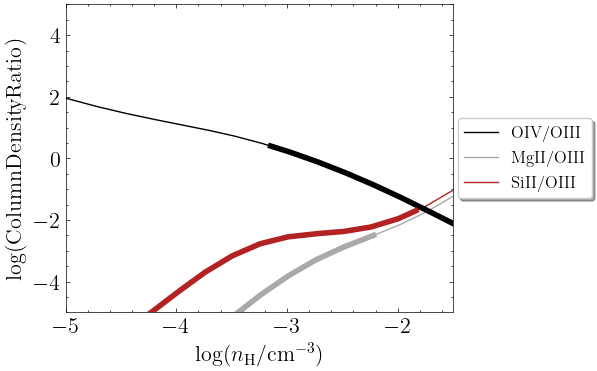

In [344]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [345]:
pos = np.array(-2.6) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [346]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [347]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [04:55<00:00,  1.69it/s]


In [348]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_hi_c4.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_hi_c4.csv')

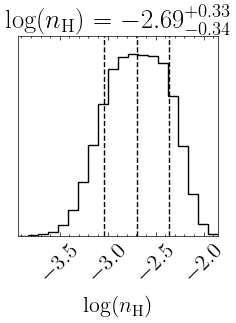

In [349]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [350]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [351]:
logN_offset = 13.5-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [352]:
logN_offset

4.950173674787079

Plot models

In [353]:
logN_dict = {#'HI' : '14.5, -0.1, +0.1',
            #'HeI' : '<12.8',
            #'CII' : '<12.7',
            #'CIII' : '<12.8',
            #'CIV' : '13.52, -0.03, +0.03',
            #'NIV' : '13.0, -0.1, +0.1',
            #'NV' : '<12.9',
            'OIII' : '13.5, -0.1, +0.1',
            'OIV' : '<13.9',
            #'OV' : '<12.2',
            #'OVI' : '14.1, -0.1, +0.1',
            'MgII' : '<11.0',
            #'MgX' : '<13.2',
            #'AlII' : '<10.8',
            #'AlIII' : '<11.2',
            'SiII' : '<11.8',
            'SIV' : '<13.6',}
            #'SVI' : '<13.1',
            #'FeII' : '<11.2',}

In [354]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

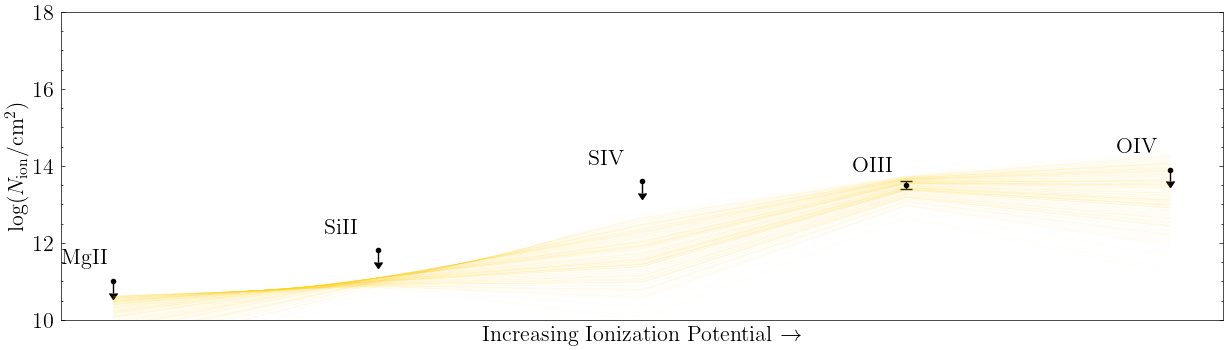

In [355]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='gold', lw=.2, alpha=.1)

In [356]:
get_cloud_size(14.5, -2.7, species_logN_interp)

0.06872594840200906